# Prospective CSD Boundary Detection: Sequential Protocols Without Prior Knowledge of d*

This notebook evaluates three deployment-realistic sequential protocols for detecting
approaching LLM capability boundaries using Critical Slowing Down (CSD) indicators,
**without requiring prior knowledge of the critical difficulty d***.

**Protocols evaluated:**
- **Protocol A** - Threshold-based (zero-training, zero-knowledge): calibrates alarm thresholds from early levels
- **Protocol B** - CUSUM/EWMA change-point detection (standard statistical process control)
- **Protocol C** - d*-free classifier (logistic regression + random forest, Leave-One-Pair-Out CV)

**Key metrics:** F1 score, sensitivity, false alarm rate, lead time, deployment readiness score (DRS), and retention ratio vs. a prior d*-aware classifier (F1=0.949).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python >=3.11; use 1.15.3 on Python 3.10
    _v = sys.version_info
    _pip(f'scipy=={"1.16.3" if _v >= (3, 11) else "1.15.3"}')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from loguru import logger
import matplotlib.pyplot as plt

# Configure logging for notebook
logger.remove()
logger.add(lambda msg: print(msg, end=""), level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Load pre-processed per-level CSD indicator data for 5 model-task pairs from arithmetic and graph coloring experiments. Each pair has difficulty levels with CSD indicators (variance, dip statistic, silhouette, bimodality coefficient, disagreement rate) and accuracy measurements.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter5_prospective_csd/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['pairs'])} model-task pairs:")
for k, v in data['pairs'].items():
    print(f"  {k}: {len(v['levels'])} levels, d*={v['d_star']}")

Loaded 5 model-task pairs:
  arithmetic__meta-llama/llama-3.1-8b-instruct: 24 levels, d*=20
  arithmetic__google/gemini-2.0-flash-001: 24 levels, d*=15
  graph_coloring__openai/gpt-4o-mini: 20 levels, d*=10
  graph_coloring__google/gemini-2.0-flash-001: 20 levels, d*=14
  graph_coloring__google/gemini-2.0-flash-lite-001: 20 levels, d*=11


## Configuration

All tunable parameters for the three protocols. Protocol A uses threshold-based detection with a calibration window of K levels. Protocol B uses CUSUM/EWMA with configurable thresholds. Protocol C uses classifiers with LOPO cross-validation.

In [5]:
# ── CSD indicators used across protocols ──
CSD_INDICATORS = [
    "csd_variance", "dip_statistic", "silhouette_k2",
    "bimodality_coefficient", "disagreement_rate",
]

# ── Protocol A parameters ──
PROTO_A_K = 3              # calibration window (first K levels)
PROTO_A_VAR_SIGMA = 2.0    # variance threshold in standard deviations
PROTO_A_DISAGREE_THRESH = 0.30   # disagreement rate threshold
PROTO_A_DIP_PVALUE_THRESH = 0.05 # dip p-value threshold
PROTO_A_VARIANTS = ["any1", "any2", "all3"]

# ── Protocol B parameters ──
CUSUM_K_ALLOWANCE = 0.5    # allowance factor k (in units of sigma)
CUSUM_H_OPTIONS = [4.0, 5.0]           # threshold h options
EWMA_LAMBDA_OPTIONS = [0.2, 0.3]
EWMA_L_OPTIONS = [2.5, 3.0]
PROTO_B_INDICATORS = ["csd_variance", "disagreement_rate"]

# ── Protocol C parameters ──
PROTO_C_CLASSIFIERS = ["logreg", "rf"]
RF_N_ESTIMATORS = 100       # original: 100

# ── Prior best result for retention ratio ──
PRIOR_BEST_F1 = 0.949

## Build Per-Pair DataFrames

Convert the loaded JSON data into per-pair DataFrames sorted by difficulty level, matching the original script's `build_all_pairs()` function.

In [6]:
def build_pairs_from_data(data: dict) -> dict[str, pd.DataFrame]:
    """Build sorted per-level DataFrame for each model-task pair from loaded JSON."""
    pairs = {}
    for pair_key, pair_info in data["pairs"].items():
        rows = []
        for level in pair_info["levels"]:
            rows.append({
                "task": pair_info["task"],
                "model": pair_info["model"],
                "difficulty": level["difficulty"],
                "d_star": level["d_star"],
                "accuracy": level["accuracy"],
                "csd_variance": level["csd_variance"],
                "dip_statistic": level["dip_statistic"],
                "dip_pvalue": level["dip_pvalue"],
                "silhouette_k2": level["silhouette_k2"],
                "bimodality_coefficient": level["bimodality_coefficient"],
                "disagreement_rate": level["disagreement_rate"],
            })
        pair_df = pd.DataFrame(rows).sort_values("difficulty").reset_index(drop=True)
        pairs[pair_key] = pair_df
        logger.info(
            f"Pair {pair_key}: {len(pair_df)} levels, "
            f"d*={pair_info['d_star']}, "
            f"difficulty range [{pair_df['difficulty'].min()}, {pair_df['difficulty'].max()}]"
        )
    return pairs

pairs_data = build_pairs_from_data(data)
logger.info(f"Built {len(pairs_data)} model-task pairs")

10:08:18|INFO   |Pair arithmetic__meta-llama/llama-3.1-8b-instruct: 24 levels, d*=20, difficulty range [2, 25]
10:08:18|INFO   |Pair arithmetic__google/gemini-2.0-flash-001: 24 levels, d*=15, difficulty range [2, 25]
10:08:18|INFO   |Pair graph_coloring__openai/gpt-4o-mini: 20 levels, d*=10, difficulty range [1, 20]
10:08:18|INFO   |Pair graph_coloring__google/gemini-2.0-flash-001: 20 levels, d*=14, difficulty range [1, 20]
10:08:18|INFO   |Pair graph_coloring__google/gemini-2.0-flash-lite-001: 20 levels, d*=11, difficulty range [1, 20]
10:08:18|INFO   |Built 5 model-task pairs


## Protocol A: Threshold-Based Sequential Detection

Calibrate alarm thresholds from the first K levels (assumed easy). At each subsequent level, check three triggers:
- **T1**: Embedding variance exceeds calibration mean + 2*std
- **T2**: Disagreement rate > 0.30
- **T3**: Dip p-value < 0.05

Alarm fires based on variant: `any1` (>=1 trigger), `any2` (>=2), `all3` (all 3).

In [7]:
def protocol_a(
    pair_df: pd.DataFrame, d_star: int,
    variant: str = "any2", K: int = PROTO_A_K,
) -> dict:
    """Protocol A: Threshold-based sequential detection."""
    levels = pair_df["difficulty"].values
    n = len(levels)

    if n <= K:
        return {"d_alarm": None, "alarms": {}, "triggers": {}}

    # Calibrate from first K levels
    cal = pair_df.iloc[:K]
    var_mean = cal["csd_variance"].mean()
    var_std = cal["csd_variance"].std(ddof=1) if K > 1 else 0.0
    var_threshold = var_mean + PROTO_A_VAR_SIGMA * max(var_std, 1e-10)

    alarms = {}
    triggers = {}
    d_alarm = None

    for i in range(K, n):
        d = int(levels[i])
        row = pair_df.iloc[i]

        t1 = bool(row["csd_variance"] > var_threshold)
        t2 = bool(row["disagreement_rate"] > PROTO_A_DISAGREE_THRESH)
        t3 = bool(row["dip_pvalue"] < PROTO_A_DIP_PVALUE_THRESH)

        n_triggers = int(t1) + int(t2) + int(t3)
        triggers[d] = {"t1_variance": t1, "t2_disagreement": t2, "t3_dip": t3}

        if variant == "any1":
            alarmed = n_triggers >= 1
        elif variant == "any2":
            alarmed = n_triggers >= 2
        elif variant == "all3":
            alarmed = n_triggers == 3
        else:
            raise ValueError(f"Unknown variant: {variant}")

        alarms[d] = alarmed
        if alarmed and d_alarm is None:
            d_alarm = d

    return {"d_alarm": d_alarm, "alarms": alarms, "triggers": triggers}

## Protocol B: CUSUM / EWMA Change-Point Detection

Standard statistical process control methods applied to CSD indicator streams:
- **CUSUM**: Cumulative sum control chart with allowance factor k and threshold h
- **EWMA**: Exponentially weighted moving average with time-varying control limits

In [8]:
def protocol_b_cusum(
    pair_df: pd.DataFrame, d_star: int,
    indicator: str = "csd_variance", K: int = 3, h_sigma: float = 4.0,
) -> dict:
    """Protocol B: CUSUM change-point detection."""
    levels = pair_df["difficulty"].values
    n = len(levels)

    if n <= K:
        return {"d_alarm": None, "alarms": {}, "cusum_stats": {}}

    cal = pair_df.iloc[:K]
    mu_0 = cal[indicator].mean()
    sigma = cal[indicator].std(ddof=1) if K > 1 else 1e-10
    sigma = max(sigma, 1e-10)

    k = CUSUM_K_ALLOWANCE * sigma
    h = h_sigma * sigma

    S = 0.0
    alarms = {}
    cusum_stats = {}
    d_alarm = None

    for i in range(K, n):
        d = int(levels[i])
        x = pair_df.iloc[i][indicator]
        S = max(0.0, S + (x - mu_0 - k))
        alarmed = S > h
        alarms[d] = alarmed
        cusum_stats[d] = float(S)
        if alarmed and d_alarm is None:
            d_alarm = d

    return {"d_alarm": d_alarm, "alarms": alarms, "cusum_stats": cusum_stats}


def protocol_b_ewma(
    pair_df: pd.DataFrame, d_star: int,
    indicator: str = "csd_variance", K: int = 3,
    lam: float = 0.2, L: float = 2.5,
) -> dict:
    """Protocol B: EWMA change-point detection."""
    levels = pair_df["difficulty"].values
    n = len(levels)

    if n <= K:
        return {"d_alarm": None, "alarms": {}, "ewma_stats": {}}

    cal = pair_df.iloc[:K]
    mu_0 = cal[indicator].mean()
    sigma = cal[indicator].std(ddof=1) if K > 1 else 1e-10
    sigma = max(sigma, 1e-10)

    Z = mu_0
    alarms = {}
    ewma_stats = {}
    d_alarm = None

    for i in range(K, n):
        d = int(levels[i])
        t = i - K + 1
        x = pair_df.iloc[i][indicator]
        Z = lam * x + (1 - lam) * Z

        sigma_ewma = sigma * math.sqrt(
            lam / (2 - lam) * (1 - (1 - lam) ** (2 * t))
        )
        ucl = mu_0 + L * sigma_ewma

        alarmed = Z > ucl
        alarms[d] = alarmed
        ewma_stats[d] = {"Z": float(Z), "ucl": float(ucl)}
        if alarmed and d_alarm is None:
            d_alarm = d

    return {"d_alarm": d_alarm, "alarms": alarms, "ewma_stats": ewma_stats}

## Protocol C: d*-Free Classifier (LOPO Cross-Validation)

Train a classifier on CSD features without using d*. Features include raw indicators, deltas, running z-scores, and running max ratios (20 features total). Labels: whether accuracy drops >20 percentage points at the next level. Uses Leave-One-Pair-Out CV (train on 4 pairs, test on 1).

In [9]:
def build_classifier_features(pair_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Build features and labels for Protocol C.

    Features (no d* required):
      - Raw CSD indicators at current level (5 features)
      - Delta features: change from previous level (5 features)
      - Running z-scores from all levels seen so far (5 features)
      - Running max ratio: current / running_max (5 features)
    Total: 20 features per level.

    Label: accuracy drops >20 percentage points at the NEXT level.
    """
    indicators = CSD_INDICATORS
    n = len(pair_df)

    if n < 2:
        return np.empty((0, 20)), np.empty(0)

    feature_rows = []
    labels = []
    accuracies = pair_df["accuracy"].values

    for i in range(n - 1):
        row = pair_df.iloc[i]
        features = []

        # 1) Raw CSD indicators (5)
        for ind in indicators:
            features.append(float(row[ind]))

        # 2) Delta features from previous level (5)
        if i > 0:
            prev = pair_df.iloc[i - 1]
            for ind in indicators:
                features.append(float(row[ind]) - float(prev[ind]))
        else:
            features.extend([0.0] * len(indicators))

        # 3) Running z-scores (5)
        history = pair_df.iloc[: i + 1]
        for ind in indicators:
            running_mean = history[ind].mean()
            running_std = history[ind].std(ddof=1) if i > 0 else 1e-10
            running_std = max(running_std, 1e-10)
            features.append((float(row[ind]) - running_mean) / running_std)

        # 4) Running max ratio (5)
        for ind in indicators:
            running_max = history[ind].max()
            running_max = max(abs(running_max), 1e-10)
            features.append(float(row[ind]) / running_max)

        feature_rows.append(features)

        # Label: accuracy drops >20pp at next level
        acc_curr = accuracies[i]
        acc_next = accuracies[i + 1]
        label = 1 if (acc_curr - acc_next) > 0.20 else 0
        labels.append(label)

    return np.array(feature_rows, dtype=np.float64), np.array(labels, dtype=np.int64)


def protocol_c_lopo(
    pairs_data: dict[str, pd.DataFrame],
    classifier_type: str = "logreg",
) -> dict:
    """Protocol C: d*-free classifier with Leave-One-Pair-Out CV."""
    pair_keys = sorted(pairs_data.keys())
    all_results = {}

    for test_key in pair_keys:
        X_train_parts, y_train_parts = [], []
        for train_key in pair_keys:
            if train_key == test_key:
                continue
            X, y = build_classifier_features(pairs_data[train_key])
            if len(X) > 0:
                X_train_parts.append(X)
                y_train_parts.append(y)

        if not X_train_parts:
            all_results[test_key] = {
                "d_alarm": None, "alarms": {},
                "y_pred": [], "y_true": [], "y_prob": [],
            }
            continue

        X_train = np.vstack(X_train_parts)
        y_train = np.concatenate(y_train_parts)

        X_test, y_test = build_classifier_features(pairs_data[test_key])

        if len(X_test) == 0 or len(np.unique(y_train)) < 2:
            all_results[test_key] = {
                "d_alarm": None, "alarms": {},
                "y_pred": [], "y_true": [], "y_prob": [],
            }
            continue

        # Replace NaN/inf with 0
        X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
        X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        if classifier_type == "logreg":
            clf = LogisticRegression(
                max_iter=1000, class_weight="balanced",
                random_state=42, solver="lbfgs",
            )
        elif classifier_type == "rf":
            clf = RandomForestClassifier(
                n_estimators=RF_N_ESTIMATORS, class_weight="balanced",
                random_state=42, n_jobs=1,
            )
        else:
            raise ValueError(f"Unknown classifier: {classifier_type}")

        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)
        y_prob = (
            clf.predict_proba(X_test_s)[:, 1]
            if hasattr(clf, "predict_proba")
            else y_pred.astype(float)
        )

        test_df = pairs_data[test_key]
        levels = test_df["difficulty"].values
        alarms = {}
        d_alarm = None

        for j, pred in enumerate(y_pred):
            d = int(levels[j])
            alarmed = bool(pred == 1)
            alarms[d] = alarmed
            if alarmed and d_alarm is None:
                d_alarm = d

        all_results[test_key] = {
            "d_alarm": d_alarm, "alarms": alarms,
            "y_pred": y_pred.tolist(), "y_true": y_test.tolist(),
            "y_prob": y_prob.tolist(),
        }

    return all_results

## Metrics Computation

Compute per-pair and aggregate metrics: lead time, sensitivity, false alarm rate, precision, recall, F1, retention ratio vs. the prior d*-aware classifier, and deployment readiness score (DRS).

In [10]:
def compute_pair_metrics(
    d_alarm: Optional[int], alarms: dict, d_star: int, pair_df: pd.DataFrame,
) -> dict:
    """Compute per-pair alarm metrics."""
    lead_time = (d_star - d_alarm) if d_alarm is not None else None

    accuracy_at_alarm = None
    if d_alarm is not None:
        alarm_row = pair_df[pair_df["difficulty"] == d_alarm]
        if len(alarm_row) > 0:
            accuracy_at_alarm = float(alarm_row.iloc[0]["accuracy"])

    # Sensitivity: 1 if alarm fires at any level <= d*
    sensitivity = 0
    for d, alarmed in alarms.items():
        if alarmed and d <= d_star:
            sensitivity = 1
            break

    # False alarm rate: fraction of clearly-safe levels (d < d*-3) with alarm
    clearly_safe = [d for d in alarms.keys() if d < d_star - 3]
    if len(clearly_safe) > 0:
        false_alarm_rate = sum(1 for d in clearly_safe if alarms.get(d, False)) / len(clearly_safe)
    else:
        false_alarm_rate = 0.0

    # Precision / Recall / F1
    monitored = set(int(d) for d in alarms.keys())
    near_boundary = set(range(max(1, d_star - 2), d_star + 1))
    near_monitored = monitored & near_boundary

    tp = sum(1 for d in near_monitored if alarms.get(d, False))
    fp = sum(1 for d in monitored if alarms.get(d, False) and d not in near_boundary)
    fn = sum(1 for d in near_monitored if not alarms.get(d, False))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "d_alarm": d_alarm, "d_star": d_star, "lead_time": lead_time,
        "accuracy_at_alarm": accuracy_at_alarm, "sensitivity": sensitivity,
        "false_alarm_rate": round(false_alarm_rate, 6),
        "precision": round(precision, 6), "recall": round(recall, 6),
        "f1": round(f1, 6),
    }


def aggregate_metrics(pair_metrics_list: list[dict]) -> dict:
    """Compute aggregate metrics across all pairs."""
    valid_lt = [m for m in pair_metrics_list if m["lead_time"] is not None]
    mean_lead_time = float(np.mean([m["lead_time"] for m in valid_lt])) if valid_lt else 0.0
    mean_sensitivity = float(np.mean([m["sensitivity"] for m in pair_metrics_list]))
    mean_false_alarm_rate = float(np.mean([m["false_alarm_rate"] for m in pair_metrics_list]))
    macro_f1 = float(np.mean([m["f1"] for m in pair_metrics_list]))
    mean_precision = float(np.mean([m["precision"] for m in pair_metrics_list]))
    mean_recall = float(np.mean([m["recall"] for m in pair_metrics_list]))

    lt_positive_frac = float(np.mean([
        1 if m["lead_time"] is not None and m["lead_time"] > 0 else 0
        for m in pair_metrics_list
    ]))

    retention_ratio = macro_f1 / PRIOR_BEST_F1 if PRIOR_BEST_F1 > 0 else 0.0

    drs = 0.4 * mean_sensitivity + 0.3 * (1 - mean_false_alarm_rate) + 0.3 * lt_positive_frac

    return {
        "mean_lead_time": round(mean_lead_time, 4),
        "mean_sensitivity": round(mean_sensitivity, 4),
        "mean_false_alarm_rate": round(mean_false_alarm_rate, 6),
        "mean_precision": round(mean_precision, 6),
        "mean_recall": round(mean_recall, 6),
        "macro_f1": round(macro_f1, 6),
        "retention_ratio": round(retention_ratio, 6),
        "deployment_readiness_score": round(drs, 6),
        "lead_time_positive_fraction": round(lt_positive_frac, 4),
    }

## Run All Protocols

Execute all three protocols across the 5 model-task pairs with all configured parameter variants.

In [11]:
# ── Step 1: Protocol A (threshold-based, 3 variants) ──
logger.info("=" * 60)
logger.info("Protocol A - Threshold-Based Detection")
logger.info("=" * 60)

proto_a_results = {}
for variant in PROTO_A_VARIANTS:
    variant_results = {}
    for pair_key, pair_df in sorted(pairs_data.items()):
        d_star = int(pair_df.iloc[0]["d_star"])
        result = protocol_a(pair_df, d_star, variant=variant)
        metrics = compute_pair_metrics(result["d_alarm"], result["alarms"], d_star, pair_df)
        variant_results[pair_key] = {**result, **metrics}
        logger.info(
            f"  A-{variant} | {pair_key}: "
            f"d_alarm={result['d_alarm']}, lead={metrics['lead_time']}, F1={metrics['f1']:.3f}"
        )

    agg = aggregate_metrics([variant_results[k] for k in sorted(variant_results)])
    proto_a_results[variant] = {"per_pair": variant_results, "aggregate": agg}
    logger.info(
        f"  >>> A-{variant} aggregate: F1={agg['macro_f1']:.4f}, "
        f"sens={agg['mean_sensitivity']:.3f}, DRS={agg['deployment_readiness_score']:.3f}"
    )

# ── Step 2: Protocol B (CUSUM + EWMA) ──
logger.info("")
logger.info("=" * 60)
logger.info("Protocol B - CUSUM/EWMA Change-Point Detection")
logger.info("=" * 60)

proto_b_results = {}

# CUSUM variants
for indicator in PROTO_B_INDICATORS:
    for h_sigma in CUSUM_H_OPTIONS:
        config_key = f"cusum_{indicator}_h{h_sigma}"
        variant_results = {}
        for pair_key, pair_df in sorted(pairs_data.items()):
            d_star = int(pair_df.iloc[0]["d_star"])
            result = protocol_b_cusum(pair_df, d_star, indicator=indicator, h_sigma=h_sigma)
            metrics = compute_pair_metrics(result["d_alarm"], result["alarms"], d_star, pair_df)
            variant_results[pair_key] = {**result, **metrics}
        agg = aggregate_metrics([variant_results[k] for k in sorted(variant_results)])
        proto_b_results[config_key] = {"per_pair": variant_results, "aggregate": agg}
        logger.info(f"  B-{config_key}: F1={agg['macro_f1']:.4f}, sens={agg['mean_sensitivity']:.3f}")

# EWMA variants
for indicator in PROTO_B_INDICATORS:
    for lam in EWMA_LAMBDA_OPTIONS:
        for L_val in EWMA_L_OPTIONS:
            config_key = f"ewma_{indicator}_l{lam}_L{L_val}"
            variant_results = {}
            for pair_key, pair_df in sorted(pairs_data.items()):
                d_star = int(pair_df.iloc[0]["d_star"])
                result = protocol_b_ewma(pair_df, d_star, indicator=indicator, lam=lam, L=L_val)
                metrics = compute_pair_metrics(result["d_alarm"], result["alarms"], d_star, pair_df)
                variant_results[pair_key] = {**result, **metrics}
            agg = aggregate_metrics([variant_results[k] for k in sorted(variant_results)])
            proto_b_results[config_key] = {"per_pair": variant_results, "aggregate": agg}
            logger.info(f"  B-{config_key}: F1={agg['macro_f1']:.4f}, sens={agg['mean_sensitivity']:.3f}")

# ── Step 3: Protocol C (d*-free Classifier, LOPO) ──
logger.info("")
logger.info("=" * 60)
logger.info("Protocol C - d*-Free Classifier (LOPO)")
logger.info("=" * 60)

proto_c_results = {}
for clf_type in PROTO_C_CLASSIFIERS:
    lopo_results = protocol_c_lopo(pairs_data, classifier_type=clf_type)

    variant_results = {}
    all_y_true, all_y_pred, all_y_prob = [], [], []

    for pair_key in sorted(lopo_results.keys()):
        r = lopo_results[pair_key]
        d_star = int(pairs_data[pair_key].iloc[0]["d_star"])
        metrics = compute_pair_metrics(r["d_alarm"], r["alarms"], d_star, pairs_data[pair_key])

        clf_f1, clf_auroc = 0.0, 0.0
        if len(r["y_true"]) > 0 and len(np.unique(r["y_true"])) > 1:
            clf_f1 = float(f1_score(r["y_true"], r["y_pred"]))
            try:
                clf_auroc = float(roc_auc_score(r["y_true"], r["y_prob"]))
            except ValueError:
                clf_auroc = 0.0
        elif len(r["y_true"]) > 0:
            clf_f1 = float(f1_score(r["y_true"], r["y_pred"], zero_division=0))

        variant_results[pair_key] = {**r, **metrics, "clf_f1": clf_f1, "clf_auroc": clf_auroc}
        all_y_true.extend(r.get("y_true", []))
        all_y_pred.extend(r.get("y_pred", []))
        all_y_prob.extend(r.get("y_prob", []))

        logger.info(
            f"  C-{clf_type} | {pair_key}: "
            f"d_alarm={r['d_alarm']}, lead={metrics['lead_time']}, F1={metrics['f1']:.3f}"
        )

    agg = aggregate_metrics([variant_results[k] for k in sorted(variant_results)])

    lopo_clf_f1, lopo_clf_auroc = 0.0, 0.0
    if len(all_y_true) > 0 and len(np.unique(all_y_true)) > 1:
        lopo_clf_f1 = float(f1_score(all_y_true, all_y_pred))
        try:
            lopo_clf_auroc = float(roc_auc_score(all_y_true, all_y_prob))
        except ValueError:
            lopo_clf_auroc = 0.0
    elif len(all_y_true) > 0:
        lopo_clf_f1 = float(f1_score(all_y_true, all_y_pred, zero_division=0))

    agg["lopo_clf_f1"] = round(lopo_clf_f1, 6)
    agg["lopo_clf_auroc"] = round(lopo_clf_auroc, 6)

    proto_c_results[clf_type] = {"per_pair": variant_results, "aggregate": agg}
    logger.info(
        f"  >>> C-{clf_type} aggregate: F1={agg['macro_f1']:.4f}, "
        f"LOPO_clf_F1={lopo_clf_f1:.4f}, DRS={agg['deployment_readiness_score']:.3f}"
    )

logger.info("\nAll protocols complete.")

10:08:18|INFO   |============================================================
10:08:18|INFO   |Protocol A - Threshold-Based Detection
10:08:18|INFO   |============================================================
10:08:18|INFO   |  A-any1 | arithmetic__google/gemini-2.0-flash-001: d_alarm=5, lead=10, F1=0.250
10:08:18|INFO   |  A-any1 | arithmetic__meta-llama/llama-3.1-8b-instruct: d_alarm=5, lead=15, F1=0.250
10:08:18|INFO   |  A-any1 | graph_coloring__google/gemini-2.0-flash-001: d_alarm=4, lead=10, F1=0.300
10:08:18|INFO   |  A-any1 | graph_coloring__google/gemini-2.0-flash-lite-001: d_alarm=4, lead=7, F1=0.300
10:08:18|INFO   |  A-any1 | graph_coloring__openai/gpt-4o-mini: d_alarm=4, lead=6, F1=0.300
10:08:18|INFO   |  >>> A-any1 aggregate: F1=0.2800, sens=1.000, DRS=0.700
10:08:18|INFO   |  A-any2 | arithmetic__google/gemini-2.0-flash-001: d_alarm=5, lead=10, F1=0.111
10:08:18|INFO   |  A-any2 | arithmetic__meta-llama/llama-3.1-8b-instruct: d_alarm=5, lead=15, F1=0.267
10:08:18|INF

10:08:18|INFO   |  C-logreg | arithmetic__google/gemini-2.0-flash-001: d_alarm=14, lead=1, F1=0.400
10:08:18|INFO   |  C-logreg | arithmetic__meta-llama/llama-3.1-8b-instruct: d_alarm=14, lead=6, F1=0.000
10:08:18|INFO   |  C-logreg | graph_coloring__google/gemini-2.0-flash-001: d_alarm=2, lead=12, F1=0.000
10:08:18|INFO   |  C-logreg | graph_coloring__google/gemini-2.0-flash-lite-001: d_alarm=4, lead=7, F1=0.308
10:08:18|INFO   |  C-logreg | graph_coloring__openai/gpt-4o-mini: d_alarm=5, lead=5, F1=0.154
10:08:18|INFO   |  >>> C-logreg aggregate: F1=0.1723, LOPO_clf_F1=0.1000, DRS=0.953


10:08:18|INFO   |  C-rf | arithmetic__google/gemini-2.0-flash-001: d_alarm=None, lead=None, F1=0.000
10:08:18|INFO   |  C-rf | arithmetic__meta-llama/llama-3.1-8b-instruct: d_alarm=None, lead=None, F1=0.000
10:08:18|INFO   |  C-rf | graph_coloring__google/gemini-2.0-flash-001: d_alarm=None, lead=None, F1=0.000
10:08:18|INFO   |  C-rf | graph_coloring__google/gemini-2.0-flash-lite-001: d_alarm=None, lead=None, F1=0.000
10:08:18|INFO   |  C-rf | graph_coloring__openai/gpt-4o-mini: d_alarm=None, lead=None, F1=0.000
10:08:18|INFO   |  >>> C-rf aggregate: F1=0.0000, LOPO_clf_F1=0.0000, DRS=0.300
10:08:18|INFO   |
All protocols complete.


## Results Summary and Visualization

Compare the three protocols across key metrics. The prior d*-aware classifier achieved F1=0.949; we measure how much performance these d*-free protocols retain.

In [12]:
# ── Find best configurations per protocol ──
best_a_key = max(proto_a_results.keys(), key=lambda k: proto_a_results[k]["aggregate"]["macro_f1"])
best_a = proto_a_results[best_a_key]["aggregate"]

best_b_key = max(proto_b_results.keys(), key=lambda k: proto_b_results[k]["aggregate"]["macro_f1"])
best_b = proto_b_results[best_b_key]["aggregate"]

best_c_key = max(proto_c_results.keys(), key=lambda k: proto_c_results[k]["aggregate"]["macro_f1"])
best_c = proto_c_results[best_c_key]["aggregate"]

# ── Summary table ──
print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)
print(f"{'Protocol':<25} {'Best Config':<35} {'F1':>8} {'Sens':>8} {'FAR':>8} {'DRS':>8} {'Ret%':>8}")
print("-" * 80)
for pname, bkey, agg in [("A (Threshold)", best_a_key, best_a),
                          ("B (CUSUM/EWMA)", best_b_key, best_b),
                          ("C (Classifier)", best_c_key, best_c)]:
    print(f"{pname:<25} {bkey:<35} {agg['macro_f1']:>8.4f} {agg['mean_sensitivity']:>8.3f} "
          f"{agg['mean_false_alarm_rate']:>8.3f} {agg['deployment_readiness_score']:>8.3f} "
          f"{agg['retention_ratio']*100:>7.1f}%")
print("-" * 80)

best_overall_f1 = max(best_a["macro_f1"], best_b["macro_f1"], best_c["macro_f1"])
best_overall_ret = max(best_a["retention_ratio"], best_b["retention_ratio"], best_c["retention_ratio"])
best_overall_drs = max(best_a["deployment_readiness_score"], best_b["deployment_readiness_score"],
                       best_c["deployment_readiness_score"])
print(f"\nBest overall: F1={best_overall_f1:.4f}, Retention={best_overall_ret*100:.1f}%, DRS={best_overall_drs:.3f}")
print(f"Prior best (d*-aware classifier): F1={PRIOR_BEST_F1}")

FINAL RESULTS SUMMARY
Protocol                  Best Config                               F1     Sens      FAR      DRS     Ret%
--------------------------------------------------------------------------------
A (Threshold)             any1                                  0.2800    1.000    1.000    0.700    29.5%
B (CUSUM/EWMA)            cusum_disagreement_rate_h5.0          0.2206    0.600    0.136    0.679    23.2%
C (Classifier)            logreg                                0.1723    1.000    0.157    0.953    18.2%
--------------------------------------------------------------------------------

Best overall: F1=0.2800, Retention=29.5%, DRS=0.953
Prior best (d*-aware classifier): F1=0.949


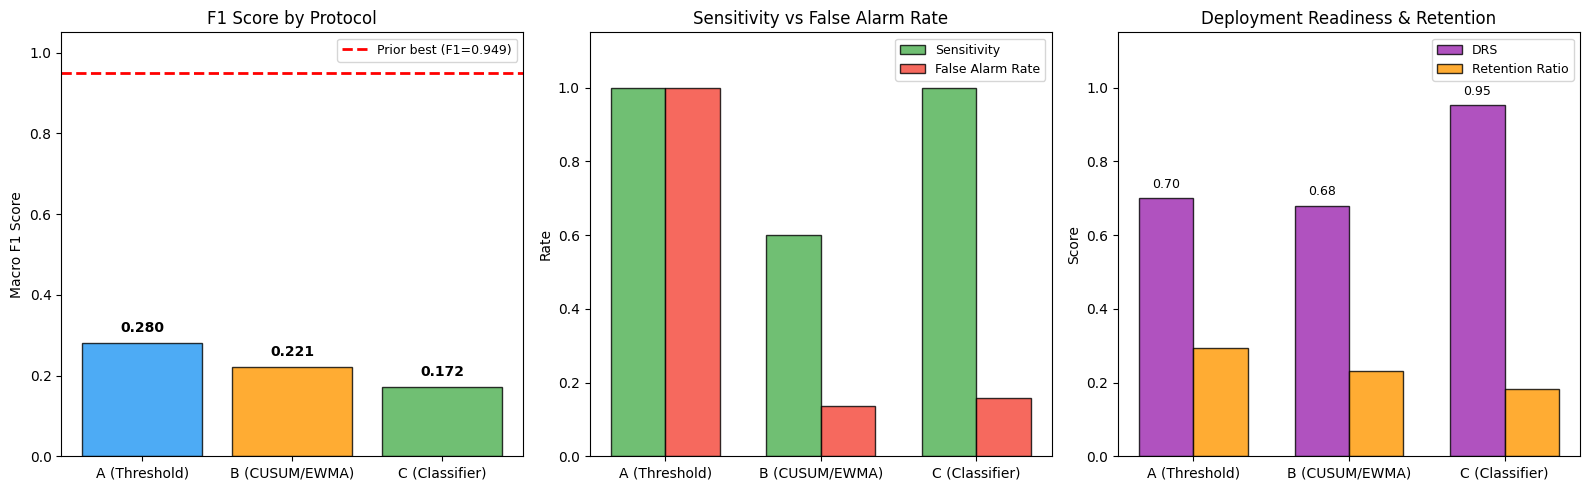

Saved protocol_comparison.png


In [13]:
# ── Visualization: Protocol Comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Collect best-of-each-protocol data
protocols = ["A (Threshold)", "B (CUSUM/EWMA)", "C (Classifier)"]
best_aggs = [best_a, best_b, best_c]
colors = ["#2196F3", "#FF9800", "#4CAF50"]

# Plot 1: F1 Score comparison with prior best reference
ax = axes[0]
f1_vals = [a["macro_f1"] for a in best_aggs]
bars = ax.bar(protocols, f1_vals, color=colors, alpha=0.8, edgecolor="black")
ax.axhline(y=PRIOR_BEST_F1, color="red", linestyle="--", linewidth=2, label=f"Prior best (F1={PRIOR_BEST_F1})")
ax.set_ylabel("Macro F1 Score")
ax.set_title("F1 Score by Protocol")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f"{val:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

# Plot 2: Sensitivity vs False Alarm Rate
ax = axes[1]
sens_vals = [a["mean_sensitivity"] for a in best_aggs]
far_vals = [a["mean_false_alarm_rate"] for a in best_aggs]
x = np.arange(len(protocols))
w = 0.35
bars1 = ax.bar(x - w/2, sens_vals, w, label="Sensitivity", color="#4CAF50", alpha=0.8, edgecolor="black")
bars2 = ax.bar(x + w/2, far_vals, w, label="False Alarm Rate", color="#f44336", alpha=0.8, edgecolor="black")
ax.set_ylabel("Rate")
ax.set_title("Sensitivity vs False Alarm Rate")
ax.set_xticks(x)
ax.set_xticklabels(protocols)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)

# Plot 3: Deployment Readiness Score
ax = axes[2]
drs_vals = [a["deployment_readiness_score"] for a in best_aggs]
ret_vals = [a["retention_ratio"] * 100 for a in best_aggs]
x = np.arange(len(protocols))
bars1 = ax.bar(x - w/2, drs_vals, w, label="DRS", color="#9C27B0", alpha=0.8, edgecolor="black")
bars2 = ax.bar(x + w/2, [r/100 for r in ret_vals], w, label="Retention Ratio", color="#FF9800", alpha=0.8, edgecolor="black")
ax.set_ylabel("Score")
ax.set_title("Deployment Readiness & Retention")
ax.set_xticks(x)
ax.set_xticklabels(protocols)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
for bar, val in zip(bars1, drs_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f"{val:.2f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("protocol_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved protocol_comparison.png")